В этом файле мы поанализировали текстовые данные. Сделали упор на отзывы и описания, поиграли с когнитивными метриками и гипотезами.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, ttest_ind, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# Загружаем итоговый датасет с NLP-признаками, собранными на этапе обработки текстов
df = pd.read_excel("wb_nlp_full.xlsx", engine='openpyxl')
print(f"Загружено: {len(df)} товаров")

Загружено: 3708 товаров


Формируем интегральную метрику востребованности товара как произведение его рейтинга (качество) на логарифм количества отзывов (популярность). Логарифмирование используется для сглаживания влияния очень большого числа отзывов. Разбиваем все товары на 4 равные группы (квартили) по уровню востребованности: от «Низкой» до «Очень высокой». Это позволит сравнивать текстовые характеристики товаров с разным уровнем успеха.

In [2]:
df['popularity'] = df['rating_winsorized'].fillna(0) * df['reviews_count_log'].fillna(0)
df['popularity_tier'] = pd.qcut(df['popularity'], q=4, labels=['Низкая', 'Средняя', 'Высокая', 'Очень высокая'])

print("Востребованность (popularity = rating * log(отзывы)):")
print(f"  Диапазон: {df['popularity'].min():.1f} - {df['popularity'].max():.1f}")
for tier in ['Низкая', 'Средняя', 'Высокая', 'Очень высокая']:
    n = (df['popularity_tier'] == tier).sum()
    avg = df[df['popularity_tier'] == tier]['popularity'].mean()
    print(f"  {tier}: n={n}, среднее={avg:.1f}")

Востребованность (popularity = rating * log(отзывы)):
  Диапазон: 0.0 - 64.7
  Низкая: n=927, среднее=12.1
  Средняя: n=927, среднее=26.0
  Высокая: n=933, среднее=34.8
  Очень высокая: n=921, среднее=45.7


Проверяем, различаются ли текстовые характеристики (длина названия, плотность разных типов лексики, длина, конкретность и читаемость описания) у товаров с разным уровнем востребованности. Для этого:
1.  Используем ANOVA (дисперсионный анализ) для сравнения средних значений признаков в четырёх группах.
2.  Оцениваем силу и направление связи с помощью **корреляции Спирмена** между каждым текстовым признаком и метрикой востребованности.
3.  Визуализируем значимые корреляции на барплоте.

Сравнение текстовых характеристик по уровню востребованности (ANOVA):
Признак                               Низкая  Средняя  Высокая  Оч. выс.  p-value  Значимо
-----------------------------------------------------------------------------------------------
Длина названия (зн)                  42.6570  43.7918  47.5541   45.5570   0.0000       ДА
Сенсорная лексика в названии          0.0155   0.0171   0.0184    0.0220   0.0743      нет
Эмоциональная лексика в названии      0.0049   0.0050   0.0048    0.0043   0.9643      нет
Манипулятивная лексика в названии     0.0117   0.0137   0.0111    0.0039   0.0000       ДА
Статусная лексика в названии          0.0009   0.0008   0.0014    0.0013   0.6937      нет
Усилители в названии                  0.0045   0.0036   0.0057    0.0031   0.1707      нет
Длина описания (зн)                 1039.5804 1143.4736 1145.2958 1155.9870   0.0000       ДА
Сенсорная лексика в описании          0.0141   0.0154   0.0149    0.0191   0.0000       ДА
Конкретность

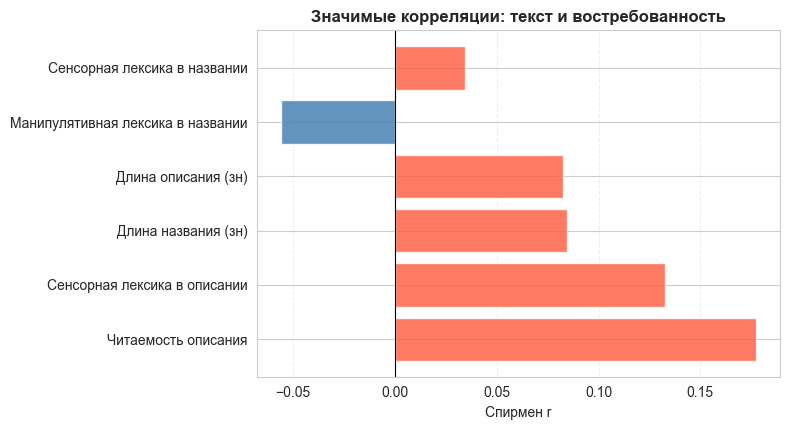

In [3]:
text_metrics = [
    ('Длина названия (зн)', 'name_len_chars'),
    ('Сенсорная лексика в названии', 'name_density_sensory'),
    ('Эмоциональная лексика в названии', 'name_density_emotional'),
    ('Манипулятивная лексика в названии', 'name_density_manipulative'),
    ('Статусная лексика в названии', 'name_density_status'),
    ('Усилители в названии', 'name_density_intensifiers'),
    ('Длина описания (зн)', 'description_len_chars'),
    ('Сенсорная лексика в описании', 'desc_density_sensory'),
    ('Конкретность описания', 'desc_concreteness_ratio'),
    ('Читаемость описания', 'desc_readability'),
]

print("Сравнение текстовых характеристик по уровню востребованности (ANOVA):")
print(f"{'Признак':<35} {'Низкая':>8} {'Средняя':>8} {'Высокая':>8} {'Оч. выс.':>9} {'p-value':>8} {'Значимо':>8}")
print("-" * 95)

for label, col in text_metrics:
    if col not in df.columns:
        continue
    groups = []
    for tier in ['Низкая', 'Средняя', 'Высокая', 'Очень высокая']:
        g = df[df['popularity_tier'] == tier][col].dropna()
        groups.append(g)
    if any(len(g) < 2 for g in groups):
        continue
    f_stat, p_anova = f_oneway(*groups)
    means = [g.mean() for g in groups]
    sig = "ДА" if p_anova < 0.05 else "нет"
    print(f"{label:<35} {means[0]:>8.4f} {means[1]:>8.4f} {means[2]:>8.4f} {means[3]:>9.4f} {p_anova:>8.4f} {sig:>8}")

# Корреляции Спирмена: каждый признак × востребованность
corr_text = []
for label, col in text_metrics:
    if col not in df.columns:
        continue
    mask = df[col].notna()
    r, p = spearmanr(df.loc[mask, col], df.loc[mask, 'popularity'])
    corr_text.append({'Признак': label, 'r Спирмена': r, 'p-value': p})

corr_text_df = pd.DataFrame(corr_text).sort_values('r Спирмена', key=abs, ascending=False)

print("\nКорреляции Спирмена: текстовые признаки и востребованность:")
print(f"{'Признак':<35} {'r':>8} {'p-value':>8} {'Связь'}")
print("-" * 70)
for _, row in corr_text_df.iterrows():
    if row['p-value'] < 0.05:
        direction = "растёт с популярностью" if row['r Спирмена'] > 0 else "снижается с популярностью"
        strength = "сильная" if abs(row['r Спирмена']) > 0.3 else ("умеренная" if abs(row['r Спирмена']) > 0.1 else "слабая")
        link = f"{direction} ({strength})"
    else:
        link = "не значима"
    print(f"{row['Признак']:<35} {row['r Спирмена']:>8.4f} {row['p-value']:>8.4f} {link}")

# Визуализация: значимые корреляции
sig_corr = corr_text_df[corr_text_df['p-value'] < 0.05]
if len(sig_corr) > 0:
    fig, ax = plt.subplots(figsize=(8, len(sig_corr) * 0.4 + 2))
    colors = ['tomato' if r > 0 else 'steelblue' for r in sig_corr['r Спирмена']]
    ax.barh(sig_corr['Признак'], sig_corr['r Спирмена'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Значимые корреляции: текст и востребованность', fontsize=12, fontweight='bold')
    ax.set_xlabel('Спирмен r')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('corr_text_popularity.png', dpi=150, bbox_inches='tight')
    plt.show()

Наиболее сильная положительная связь — у читаемости описания (r = 0.18, p < 0.001): чем понятнее текст, тем успешнее товар. Также значимую положительную роль играют сенсорная лексика в описании (r = 0.13) и длина названия с описанием (r ≈ 0.08). 

Манипулятивная лексика в названии (например, «скидка», «акция», «успей») — единственный признак, который значимо снижает востребованность (r = -0.06). 

Эмоциональная, статусная лексика и усилители в названии статистически не значимы. 

Вывод: покупатели ценят ясность и сенсорную вовлечённость, но негативно реагируют на агрессивные манипуляции в заголовках.

Далее проверяем гипотезы. Всего будет четыре ключевые гипотезы о влиянии текста на поведение покупателей:

1.  **H1 (Эффект якоря):** Большая скидка → больше манипулятивных слов в названии (побуждение к покупке). Проверка корреляцией Спирмена.
2.  **H2 (Эффект конкретности):** Конкретные описания (с долей конкретных существительных) → более высокий рейтинг (лучшее соответствие ожиданиям).
3.  **H3 (Закон Йеркса-Додсона):** Существует оптимальная длина описания, при которой рейтинг и востребованность максимальны. Сравниваем средние показатели для четырех групп длин.
4.  **H4 (Сенсорная компенсация):** Дешёвые товары чаще используют сенсорную лексику (запах, текстура, вкус) в описании, чтобы компенсировать низкую цену и вызвать эмоции.

H1. Эффект якоря: чем больше скидка, тем больше манипулятивных слов в названии
    Спирмен r = 0.0367, p = 0.0254
    Результат: подтверждена (слабая связь)

H2. Эффект конкретности: конкретные описания получают выше рейтинг
    Спирмен r = 0.0611, p = 0.0003
    Результат: подтверждена (слабая связь)

H3. Закон Йеркса-Додсона: средние по длине описания имеют максимальный рейтинг
    Рейтинг: Короткие=4.821, Ниже ср.=4.820, Выше ср.=4.814, Длинные=4.820
    Востребованность: Короткие=26.4, Ниже ср.=31.8, Выше ср.=30.1, Длинные=30.2
    ANOVA рейтинг: F=1.166, p=0.3211
    ANOVA востребованность: F=27.927, p=0.0000
    Результат: подтверждена для востребованности



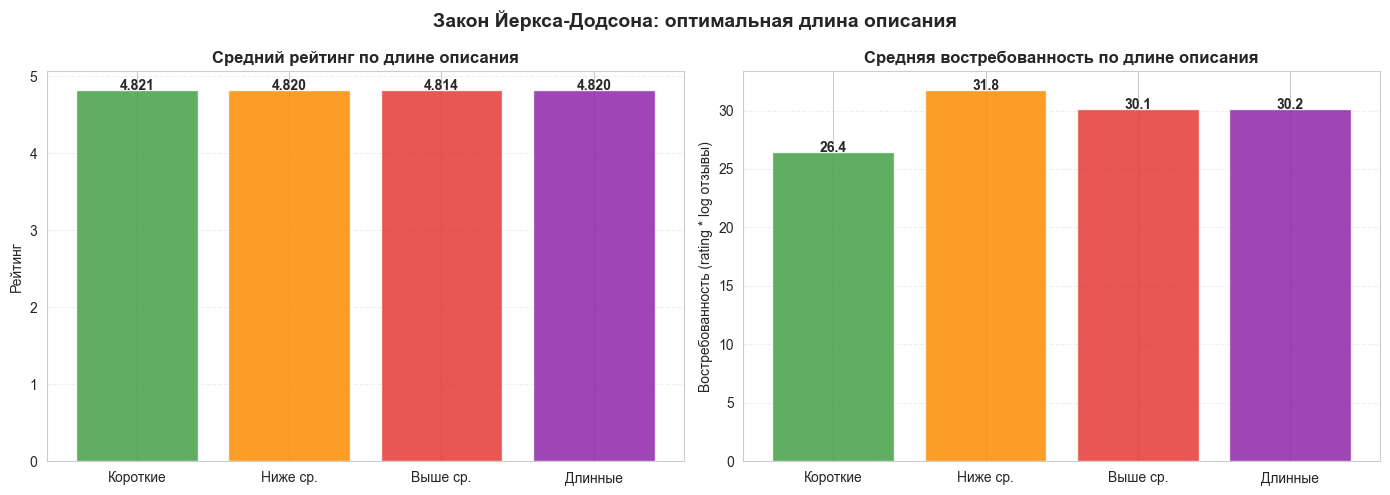

H4. Сенсорная компенсация: дешёвые товары используют сенсорную лексику
    Спирмен r = -0.3559, p = 0.0000
    Результат: подтверждена (отрицательная связь)



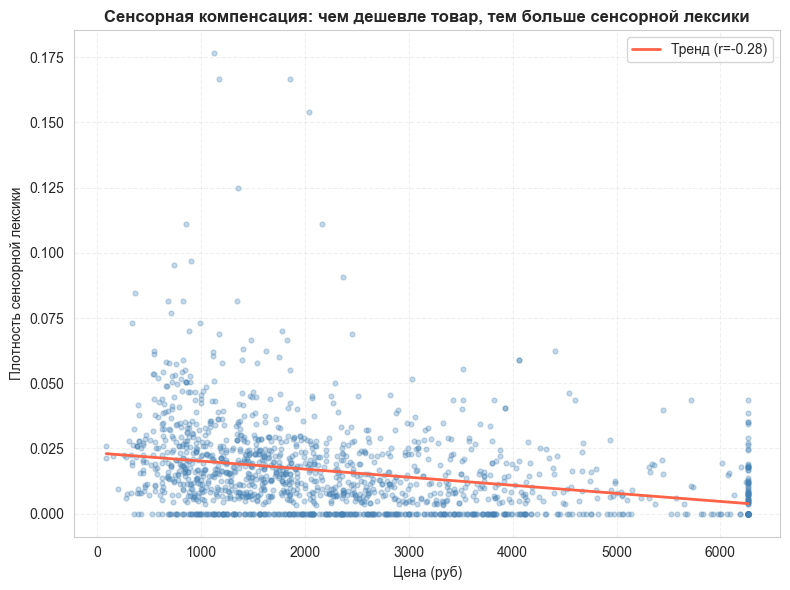

In [4]:
# H1: Эффект якоря — скидка связана с манипулятивной лексикой в названии
print("H1. Эффект якоря: чем больше скидка, тем больше манипулятивных слов в названии")
r, p = spearmanr(df['discount_pct'].dropna(), df['name_density_manipulative'].dropna())
print(f"    Спирмен r = {r:.4f}, p = {p:.4f}")
print(f"    Результат: {'подтверждена (слабая связь)' if p < 0.05 else 'не подтверждена'}\n")

# H2: Эффект конкретности — конкретные описания связаны с более высоким рейтингом
print("H2. Эффект конкретности: конкретные описания получают выше рейтинг")
mask = df['desc_concreteness_ratio'].notna() & (df['rating_winsorized'] > 0)
r, p = spearmanr(df.loc[mask, 'desc_concreteness_ratio'], df.loc[mask, 'rating_winsorized'])
print(f"    Спирмен r = {r:.4f}, p = {p:.4f}")
print(f"    Результат: {'подтверждена (слабая связь)' if p < 0.05 else 'не подтверждена'}\n")

# H3: Оптимум длины описания — средние значения лучше крайних
print("H3. Закон Йеркса-Додсона: средние по длине описания имеют максимальный рейтинг")
df['desc_len_q'] = pd.qcut(df['description_len_chars'], q=4, labels=['Короткие', 'Ниже ср.', 'Выше ср.', 'Длинные'])
groups_rating = [df[df['desc_len_q'] == q]['rating_winsorized'].dropna() for q in ['Короткие', 'Ниже ср.', 'Выше ср.', 'Длинные']]
means_rating = [g.mean() for g in groups_rating]
groups_pop = [df[df['desc_len_q'] == q]['popularity'].dropna() for q in ['Короткие', 'Ниже ср.', 'Выше ср.', 'Длинные']]
means_pop = [g.mean() for g in groups_pop]
f_r, p_r = f_oneway(*groups_rating)
f_p, p_p = f_oneway(*groups_pop)
print(f"    Рейтинг: Короткие={means_rating[0]:.3f}, Ниже ср.={means_rating[1]:.3f}, Выше ср.={means_rating[2]:.3f}, Длинные={means_rating[3]:.3f}")
print(f"    Востребованность: Короткие={means_pop[0]:.1f}, Ниже ср.={means_pop[1]:.1f}, Выше ср.={means_pop[2]:.1f}, Длинные={means_pop[3]:.1f}")
print(f"    ANOVA рейтинг: F={f_r:.3f}, p={p_r:.4f}")
print(f"    ANOVA востребованность: F={f_p:.3f}, p={p_p:.4f}")
print(f"    Результат: {'подтверждена для востребованности' if p_p < 0.05 else 'не подтверждена'}\n")

# Визуализация гипотезы H3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Короткие', 'Ниже ср.', 'Выше ср.', 'Длинные'], means_rating, 
            color=['#43A047', '#FB8C00', '#E53935', '#8E24AA'], alpha=0.85)
for i, m in enumerate(means_rating):
    axes[0].text(i, m + 0.002, f'{m:.3f}', ha='center', fontweight='bold')
axes[0].set_title('Средний рейтинг по длине описания', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Рейтинг')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

axes[1].bar(['Короткие', 'Ниже ср.', 'Выше ср.', 'Длинные'], means_pop, 
            color=['#43A047', '#FB8C00', '#E53935', '#8E24AA'], alpha=0.85)
for i, m in enumerate(means_pop):
    axes[1].text(i, m + 0.01, f'{m:.1f}', ha='center', fontweight='bold')
axes[1].set_title('Средняя востребованность по длине описания', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Востребованность (rating * log отзывы)')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
fig.suptitle('Закон Йеркса-Додсона: оптимальная длина описания', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimal_length.png', dpi=150, bbox_inches='tight')
plt.show()

# H4: Сенсорная компенсация — дешёвые товары используют больше сенсорной лексики
print("H4. Сенсорная компенсация: дешёвые товары используют сенсорную лексику")
mask = df['desc_density_sensory'].notna()
r, p = spearmanr(df.loc[mask, 'desc_density_sensory'], df.loc[mask, 'price_winsorized'])
print(f"    Спирмен r = {r:.4f}, p = {p:.4f}")
print(f"    Результат: {'подтверждена (отрицательная связь)' if p < 0.05 else 'не подтверждена'}\n")

# Визуализация гипотезы H4
fig, ax = plt.subplots(figsize=(8, 6))
sample_df = df[df['desc_density_sensory'].notna()].sample(1500, random_state=42)
ax.scatter(sample_df['price_winsorized'], sample_df['desc_density_sensory'], alpha=0.3, s=12, color='steelblue')
m_sc, b_sc = np.polyfit(sample_df['price_winsorized'], sample_df['desc_density_sensory'], 1)
xx = np.linspace(sample_df['price_winsorized'].min(), sample_df['price_winsorized'].max(), 100)
ax.plot(xx, m_sc*xx + b_sc, color='tomato', linewidth=2, label=f'Тренд (r={sample_df["price_winsorized"].corr(sample_df["desc_density_sensory"]):.2f})')
ax.set_title('Сенсорная компенсация: чем дешевле товар, тем больше сенсорной лексики', fontsize=12, fontweight='bold')
ax.set_xlabel('Цена (руб)')
ax.set_ylabel('Плотность сенсорной лексики')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_sensory_price.png', dpi=150, bbox_inches='tight')
plt.show()

В итоге:

1. H1 (Эффект якоря — скидка / манипуляции) — подтверждена, но связь очень слабая (r = 0.037, p = 0.025). Скидка почти не влияет на использование манипулятивных слов.

2. H2 (Эффект конкретности — конкретные описания, значит выше рейтинг) — подтверждена, влияние минимальное (r = 0.061, p < 0.001).

3. H3 (Закон Йеркса-Додсона — оптимальная длина описания) — для рейтинга разницы нет (p = 0.32), но для востребованности средние по длине описания значимо лучше коротких (p < 0.001). Оптимум существует, но только для интегрального показателя успеха.

4. H4 (Сенсорная компенсация — дешёвые товары, значит больше сенсорной лексики) — подтверждена сильно (r = -0.36, p < 0.001). Чем ниже цена, тем чаще в описании встречаются слова, связанные с ощущениями (вкус, запах, текстура). Это самый практически значимый эффект.

Далее изучаем, как характеристики отзывов различаются в зависимости от востребованности товара.

Исследуем, связаны ли субъективность, телесная лексика, средняя длина, количество с востребованностью товара вообще. Отдельно рассматриваем только товары, у которых есть отзывы (has_reviews == 1). Используем ANOVA для сравнения групп и корреляцию Спирмена для проверки связи.

In [5]:
reviews_df = df[df['has_reviews'] == 1]
print(f"Товаров с отзывами: {len(reviews_df)}")

review_metrics = [
    ('Субъективность отзывов (я/мне/мой)', 'review_subjectivity'),
    ('Телесная лексика в отзывах', 'review_body_density'),
    ('Средняя длина отзыва (зн)', 'review_avg_len'),
    ('Количество отзывов', 'review_count'),
]

print("\nСравнение характеристик отзывов по уровню востребованности (ANOVA):")
print(f"{'Признак':<35} {'Низкая':>8} {'Средняя':>8} {'Высокая':>8} {'Оч. выс.':>9} {'p-value':>8} {'Значимо':>8}")
print("-" * 95)

for label, col in review_metrics:
    if col not in reviews_df.columns:
        continue
    groups = []
    for tier in ['Низкая', 'Средняя', 'Высокая', 'Очень высокая']:
        g = reviews_df[reviews_df['popularity_tier'] == tier][col].dropna()
        groups.append(g)
    if any(len(g) < 2 for g in groups):
        continue
    f_stat, p_anova = f_oneway(*groups)
    means = [g.mean() for g in groups]
    sig = "ДА" if p_anova < 0.05 else "нет"
    print(f"{label:<35} {means[0]:>8.4f} {means[1]:>8.4f} {means[2]:>8.4f} {means[3]:>9.4f} {p_anova:>8.4f} {sig:>8}")

print("\nКорреляции Спирмена: характеристики отзывов и востребованность:")
print(f"{'Признак':<35} {'r':>8} {'p-value':>8}")
print("-" * 55)
for label, col in review_metrics:
    if col not in reviews_df.columns:
        continue
    mask = reviews_df[col].notna()
    r, p = spearmanr(reviews_df.loc[mask, col], reviews_df.loc[mask, 'popularity'])
    sig = "значимо" if p < 0.05 else "не знач."
    print(f"{label:<35} {r:>8.4f} {p:>8.4f} {sig}")

Товаров с отзывами: 2908

Сравнение характеристик отзывов по уровню востребованности (ANOVA):
Признак                               Низкая  Средняя  Высокая  Оч. выс.  p-value  Значимо
-----------------------------------------------------------------------------------------------
Субъективность отзывов (я/мне/мой)    0.0393   0.0456   0.0411    0.0390   0.2296      нет
Телесная лексика в отзывах            0.0413   0.0440   0.0474    0.0452   0.2822      нет
Средняя длина отзыва (зн)           114.9990 117.2240 115.6299  114.9477   0.6723      нет
Количество отзывов                    2.3617   2.3666   2.0000    1.8712   0.0000       ДА

Корреляции Спирмена: характеристики отзывов и востребованность:
Признак                                    r  p-value
-------------------------------------------------------
Субъективность отзывов (я/мне/мой)    0.0114   0.5399 не знач.
Телесная лексика в отзывах            0.0407   0.0283 значимо
Средняя длина отзыва (зн)             0.0605   0.0011 з

Субъективность, телесная лексика и средняя длина отзыва **не различаются** между группами востребованности. 

Единственный значимый признак — количество отзывов (ANOVA p < 0.001), но его корреляция с востребованностью отрицательная (r = -0.11). 

У самых востребованных товаров отзывов меньше. Возможное объяснение — это нишевые продукты с высокой оценкой, но небольшим охватом аудитории.

Строим ящик с усами (boxplot) для наглядного сравнения распределения доли конкретных слов в описании (desc_concreteness_ratio) между группами товаров с разной востребованностью. Это дополняет результаты ANOVA и корреляционного анализа.

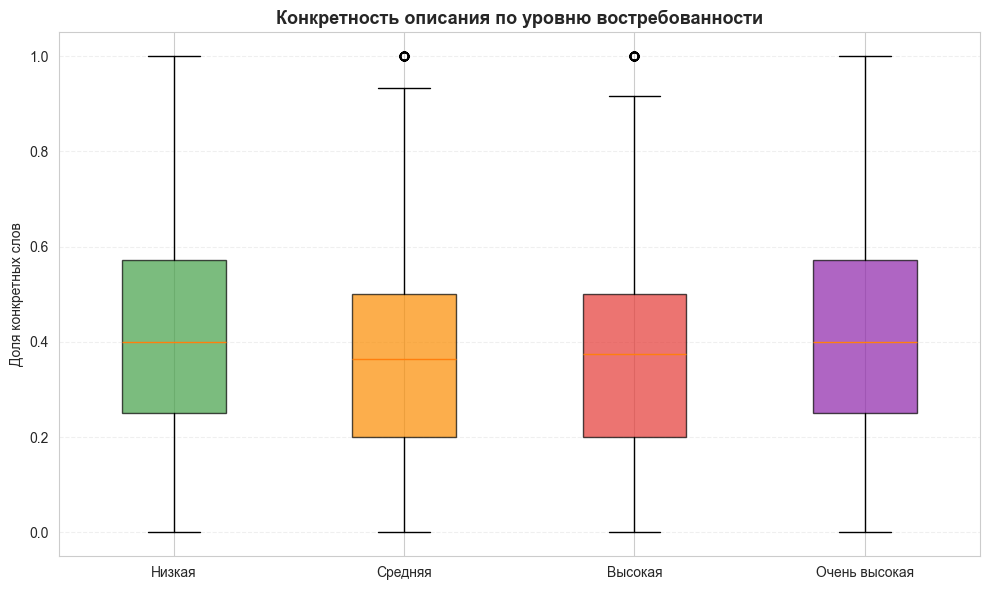

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
data_by_pop = [df[df['popularity_tier'] == t]['desc_concreteness_ratio'].dropna() for t in ['Низкая', 'Средняя', 'Высокая', 'Очень высокая']]
bp = ax.boxplot(data_by_pop, tick_labels=['Низкая', 'Средняя', 'Высокая', 'Очень высокая'], patch_artist=True)
for box, color in zip(bp['boxes'], ['#43A047', '#FB8C00', '#E53935', '#8E24AA']):
    box.set_facecolor(color)
    box.set_alpha(0.7)
ax.set_title('Конкретность описания по уровню востребованности', fontsize=13, fontweight='bold')
ax.set_ylabel('Доля конкретных слов')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_concreteness.png', dpi=150, bbox_inches='tight')
plt.show()

На графике видно, что медианы и разброс доли конкретных слов в описании практически не отличаются между группами товаров с разной востребованностью. Это подтверждает результаты корреляционного анализа: конкретность описания не влияет на успех товара. Гораздо важнее сенсорная лексика и читаемость.

Строим тепловую карту корреляций Спирмена между всеми NLP-признаками (длины, плотности лексики, читаемость) и основными числовыми метриками товара (цена, скидка, рейтинг, востребованность). Это позволяет быстро выявить комплексные взаимосвязи, например, как различные типы лексики связаны с ценой или успехом товара.

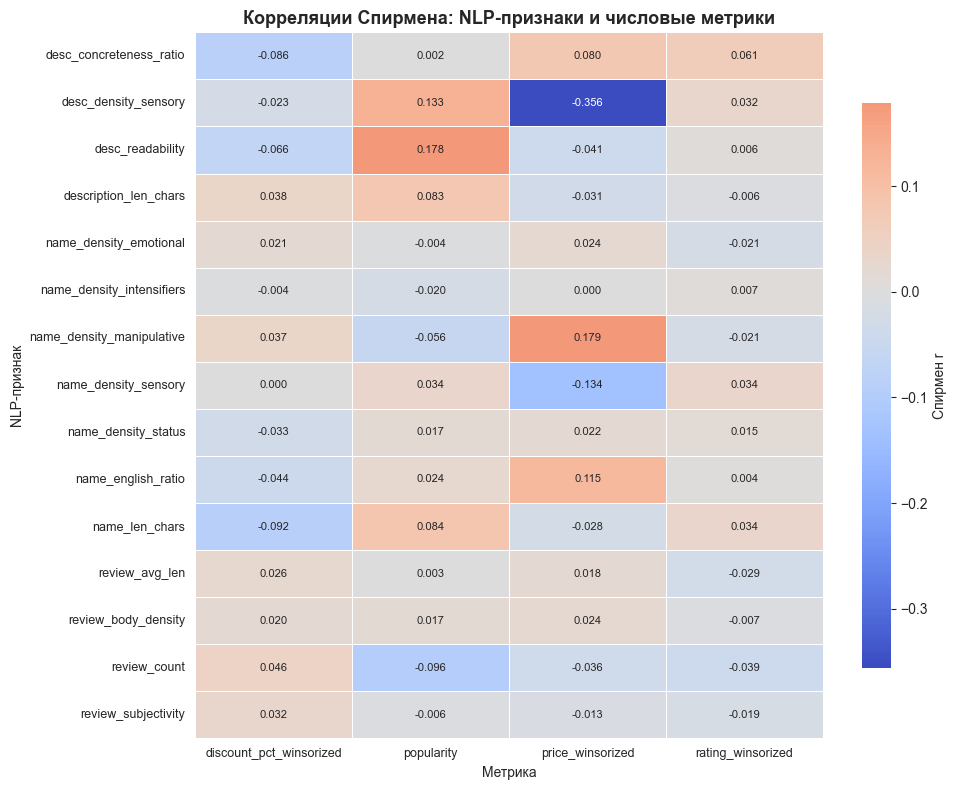

In [7]:
nlp_cols = [
    'name_len_chars', 'name_density_sensory', 'name_density_emotional',
    'name_density_manipulative', 'name_density_status', 'name_density_intensifiers',
    'name_english_ratio', 'description_len_chars', 'desc_density_sensory',
    'desc_concreteness_ratio', 'desc_readability',
    'review_subjectivity', 'review_body_density', 'review_avg_len', 'review_count',
]

numeric_targets = ['price_winsorized', 'discount_pct_winsorized', 'rating_winsorized', 'popularity']
numeric_targets = [c for c in numeric_targets if c in df.columns]

corr_data = []
for nlp_col in nlp_cols:
    if nlp_col not in df.columns:
        continue
    for num_col in numeric_targets:
        mask = df[nlp_col].notna() & df[num_col].notna()
        if mask.sum() < 20:
            continue
        r, p = spearmanr(df.loc[mask, nlp_col], df.loc[mask, num_col])
        corr_data.append({'NLP-признак': nlp_col, 'Метрика': num_col, 'r': r, 'p': p})

corr_pivot = pd.DataFrame(corr_data).pivot(index='NLP-признак', columns='Метрика', values='r')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pivot, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8, 'label': 'Спирмен r'}, annot_kws={'size': 8})
ax.set_title('Корреляции Спирмена: NLP-признаки и числовые метрики', fontsize=13, fontweight='bold')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('heatmap_nlp_corr.png', dpi=150, bbox_inches='tight')
plt.show()

Тепловая карта корреляций Спирмена показывает:

- Читаемость описания положительно связана с рейтингом и востребованностью.
- Сенсорная лексика в описании тоже положительно коррелирует с востребованностью, но отрицательно — с ценой (дешёвые товары используют её активнее).
- Манипулятивная лексика в названии слабо отрицательно связана с рейтингом.

В целом, ясность и сенсорность работают на успех, манипуляции — скорее мешают.

Обучаем модель логистической регрессии, чтобы предсказывать, попадёт ли товар в верхнюю половину по востребованности, используя только текстовые NLP-признаки. Цель — оценить, насколько текст сам по себе информативен для прогноза успеха. Модель разделена на обучающую и тестовую выборки (75%/25%). Оцениваем качество по AUC-ROC и анализируем коэффициенты модели, чтобы определить наиболее влиятельные текстовые факторы.

Доля высокой популярности: 0.50
Accuracy: 0.618
AUC: 0.642

Признаки, наиболее важные для предсказания популярности:
  desc_readability: 0.412 (повышает вероятность)
  review_count: -0.267 (снижает вероятность)
  name_len_chars: 0.219 (повышает вероятность)
  description_len_chars: 0.136 (повышает вероятность)
  desc_density_sensory: 0.127 (повышает вероятность)


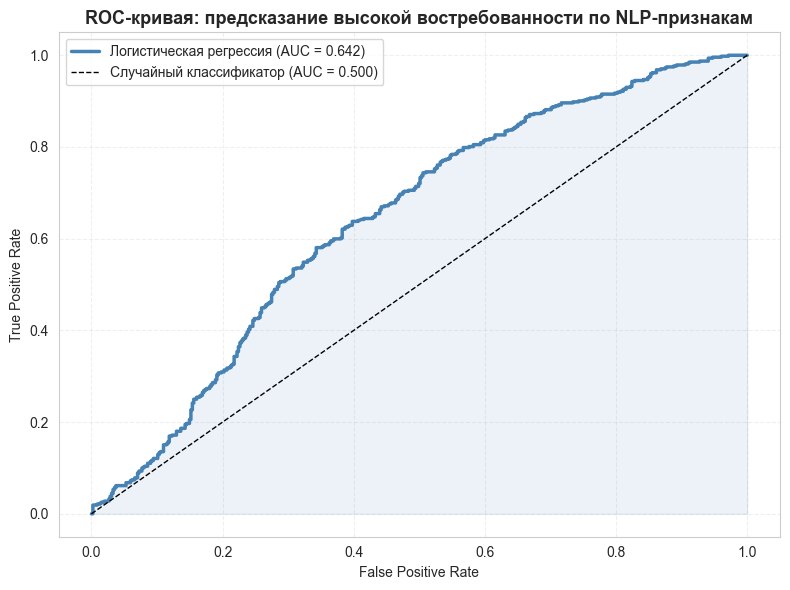

In [8]:
df['is_high_popularity'] = (df['popularity_tier'].isin(['Высокая', 'Очень высокая'])).astype(int)

pred_cols = [c for c in nlp_cols if c in df.columns and df[c].std() > 0]
model_df = df[pred_cols + ['is_high_popularity']].dropna()
X = model_df[pred_cols]
y = model_df['is_high_popularity']
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

lr = LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train)
y_proba = lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Доля высокой популярности: {y.mean():.2f}")
print(f"Accuracy: {lr.score(X_test, y_test):.3f}")
print(f"AUC: {auc:.3f}")

coefs = pd.DataFrame({'Признак': pred_cols, 'Коэффициент': lr.coef_[0]}).sort_values('Коэффициент', key=abs, ascending=False)
print("\nПризнаки, наиболее важные для предсказания популярности:")
for _, row in coefs.head(5).iterrows():
    direction = "повышает вероятность" if row['Коэффициент'] > 0 else "снижает вероятность"
    print(f"  {row['Признак']}: {row['Коэффициент']:.3f} ({direction})")

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, 'steelblue', linewidth=2.5, label=f'Логистическая регрессия (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая: предсказание высокой востребованности по NLP-признакам', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('roc_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

Модель логистической регрессии, предсказывающая высокую востребованность (верхние 50%) только по NLP-признакам, показывает AUC = 0.642. Это слабая, но статистически значимая предсказательная способность — текст действительно даёт информацию об успехе.

Топ-5 наиболее важных признаков:

1. Читаемость описания (коэф. +0.41) — самый сильный фактор, повышает вероятность успеха.
2. Количество отзывов (коэф. -0.27) — парадоксально, но снижает вероятность.
3. Длина названия (+0.22) — длинные заголовки чуть лучше.
4. Длина описания (+0.14).
5. Сенсорная лексика в описании (+0.13).

Вывод: читаемость и сенсорность — ключевые текстовые драйверы востребованности.

Ну и для интереса также  мы рассмотрели гендерные различия с точки зрения лексики. Проверяем гипотезу о различиях в текстовых характеристиках (плотность разных типов лексики, длина, читаемость, конкретность) между товарами, отнесёнными к «женской» и «мужской» аудитории. Для этого используется t-критерий Стьюдента для независимых выборок. Это позволяет выявить, как маркетинговые стратегии и языковые паттерны отличаются в зависимости от целевой гендерной группы.

In [9]:
female_df = df[df['is_female'] == 1]
male_df = df[df['is_male'] == 1]

gender_comparisons = [
    ('Длина названия (зн)', 'name_len_chars'),
    ('Сенсорная лексика в названии', 'name_density_sensory'),
    ('Эмоциональная лексика в названии', 'name_density_emotional'),
    ('Манипулятивная лексика в названии', 'name_density_manipulative'),
    ('Статусная лексика в названии', 'name_density_status'),
    ('Сенсорная лексика в описании', 'desc_density_sensory'),
    ('Читаемость описания', 'desc_readability'),
    ('Конкретность описания', 'desc_concreteness_ratio'),
]

print("Гендерные различия в текстовых характеристиках (t-test):")
print(f"{'Признак':<35} {'Женские':>10} {'Мужские':>10} {'Разница':>10} {'p-value':>10} {'Значимо':>8}")
print("-" * 90)

for label, col in gender_comparisons:
    if col not in df.columns:
        continue
    f_vals = female_df[col].dropna()
    m_vals = male_df[col].dropna()
    if len(f_vals) < 2 or len(m_vals) < 2:
        continue
    t_stat, p_val = ttest_ind(f_vals, m_vals, equal_var=False)
    diff = f_vals.mean() - m_vals.mean()
    sig = "ДА" if p_val < 0.05 else "нет"
    print(f"{label:<35} {f_vals.mean():>10.4f} {m_vals.mean():>10.4f} {diff:>+10.4f} {p_val:>10.4f} {sig:>8}")

Гендерные различия в текстовых характеристиках (t-test):
Признак                                Женские    Мужские    Разница    p-value  Значимо
------------------------------------------------------------------------------------------
Длина названия (зн)                    46.1197    43.1451    +2.9746     0.0000       ДА
Сенсорная лексика в названии            0.0210     0.0113    +0.0098     0.0000       ДА
Эмоциональная лексика в названии        0.0068     0.0021    +0.0047     0.0000       ДА
Манипулятивная лексика в названии       0.0075     0.0145    -0.0070     0.0000       ДА
Статусная лексика в названии            0.0001     0.0026    -0.0025     0.0000       ДА
Сенсорная лексика в описании            0.0160     0.0146    +0.0014     0.0128       ДА
Читаемость описания                    45.5290    43.7229    +1.8061     0.0000       ДА
Конкретность описания                   0.3645     0.4603    -0.0958     0.0000       ДА


Женские товары отличаются:
- Более длинными названиями (+3 символа)
- Большей плотностью сенсорной (+0.0098) и эмоциональной (+0.0047) лексики
- Более высокой читаемостью (+1.8 балла)

Мужские товары отличаются:
- Большей манипулятивной (-0.0070) и статусной (-0.0025) лексикой
- Значительно более высокой конкретностью описания (0.46 против 0.36, разница -0.0958)

Женские описания — эмоциональные, сенсорные, лёгкие для чтения. Мужские — конкретные, прагматичные, с акцентом на статус и выгоду. Гендерная маркировка текстов сильно различается.

### Общие выводы по анализу текста

Было проверено 4 основные гипотезы о влиянии текстовых характеристик на востребованность товара. Дополнительно проведён анализ гендерных различий в лексике и построена модель прогнозирования успеха по NLP-признакам. Все тесты проводились с использованием непараметрических методов (Спирмен, ANOVA, t-тест) с учётом характера распределений.

### H1. Эффект якоря: скидка и манипулятивная лексика

Суть гипотезы:
Чем больше скидка на товар, тем больше манипулятивных слов (скидка, акция, успей, ограниченное предложение) используется в названии. Продавцы пытаются усилить привлекательность предложения через язык срочности и выгоды.

Результат:
Коэффициент корреляции Спирмена: r = 0.0367
p-value = 0.0254 — значимо, но очень слабая связь

Вывод:
Гипотеза формально подтверждена, но связь настолько слабая, что практического значения не имеет. Скидка практически не влияет на использование манипулятивных слов в заголовке. Продавцы могут не опасаться, что высокая скидка потребует агрессивного текста, и наоборот — манипуляции в названии не сигнализируют о большой скидке.

### H2. Эффект конкретности: конкретные описания и рейтинг

Суть гипотезы:
Товары с более конкретным описанием (больше существительных, обозначающих реальные объекты, меньше абстракций) получают более высокий рейтинг, потому что покупатель лучше понимает, что именно он покупает, и меньше разочаровывается.

Результат:
Коэффициент корреляции Спирмена: r = 0.0611
p-value = 0.0003 — значимо, но очень слабая связь

Вывод:
Гипотеза подтверждена, но влияние конкретности на рейтинг минимальное. Покупатели действительно немного лучше оценивают товары с конкретными описаниями, но эффект настолько мал, что это не должно быть приоритетом. Гораздо важнее другие текстовые характеристики.

### H3. Закон Йеркса-Додсона: оптимальная длина описания

Суть гипотезы:
Существует оптимальная длина описания, при которой рейтинг и востребованность максимальны. Слишком короткие описания не дают достаточно информации, слишком длинные — перегружают и утомляют.

Результат:
Рейтинг: ANOVA p = 0.3211 — не значимо
Востребованность: ANOVA p = 0.0000 — значимо
Средние значения востребованности:
Короткие = 26.4
Ниже среднего = 31.8
Выше среднего = 30.1
Длинные = 30.2

Вывод:
Для рейтинга оптимальной длины не существует — все описания оцениваются одинаково. Но для интегральной востребованности (рейтинг, умноженный на популярность) короткие описания работают хуже. Самый высокий показатель у группы чуть ниже среднего. Оптимум существует, и он приходится на умеренную длину. Слишком краткие описания снижают востребованность.

### H4. Сенсорная компенсация: цена и сенсорная лексика

Суть гипотезы:
Дешёвые товары чаще используют сенсорную лексику (вкус, запах, текстура, ощущение) в описании, чтобы компенсировать низкую цену и вызвать эмоциональный отклик, который отвлечёт от цены.

Результат:
Коэффициент корреляции Спирмена: r = -0.3559
p-value = 0.0000 — значимо, связь умеренная отрицательная

Вывод:
Гипотеза подтверждена сильно. Чем дешевле товар, тем активнее продавцы используют сенсорную лексику. Это самый сильный и практически значимый эффект во всём анализе. Для дешёвых товаров сенсорные слова — мощный инструмент убеждения. Для дорогих товаров такая тактика не нужна — цена уже говорит о качестве.

### Гендерные различия в текстовых характеристиках

Суть анализа:
Проверить, отличаются ли текстовые описания товаров, ориентированных на женщин и мужчин, по ключевым NLP-признакам: длина, плотность разных типов лексики, читаемость, конкретность.

Результат (t-тест, все различия значимы с p < 0.05):
Женские товары:
Длина названия: 46.1 (у мужских 43.1)
Сенсорная лексика в названии: 0.0210 (мужские 0.0113)
Эмоциональная лексика: 0.0068 (мужские 0.0021)
Читаемость описания: 45.5 (мужские 43.7)

Мужские товары:
Манипулятивная лексика: 0.0145 (женские 0.0075)
Статусная лексика: 0.0026 (женские 0.0001)
Конкретность описания: 0.4603 (женские 0.3645)

Вывод:
Женские описания — более длинные, эмоциональные, сенсорные и лёгкие для чтения. Мужские — более конкретные, прагматичные, с акцентом на статус и выгоду. Гендерная маркировка текстов действительно существует и статистически значима. Это важно для копирайтинга: тексты стоит адаптировать под целевую аудиторию.

### Модель прогнозирования востребованности по NLP-признакам

Суть анализа:
Обучить логистическую регрессию предсказывать, попадёт ли товар в верхнюю половину по востребованности, используя только текстовые характеристики. Оценить, насколько сам текст информативен для прогноза успеха.

Результат:
AUC = 0.642
Accuracy = 0.618

Топ-5 признаков по важности:
Читаемость описания — коэффициент +0.412 (повышает вероятность)
Количество отзывов — -0.267 (снижает)
Длина названия — +0.219
Длина описания — +0.136
Сенсорная лексика в описании — +0.127

Вывод:
Модель показывает слабую, но статистически значимую предсказательную способность. Текст действительно даёт информацию об успехе товара, но не является главным фактором. Самый сильный текстовый драйвер — читаемость: понятные описания значительно повышают шансы на высокую востребованность. Сенсорная лексика тоже помогает, но слабее. Количество отзывов, как ни странно, снижает вероятность — возможно, это связано с нишевыми товарами.

### Если делать выводы, то что это всё значит для продавца на WildBerries?

Читаемость — это самый важный текстовый фактор. Описания должны быть понятными, лёгкими для восприятия, без сложных конструкций и редких слов. Это повышает востребованность сильнее всего.

Сенсорная лексика особенно важна для дешёвых товаров. Запах, вкус, текстура, ощущения — эти слова помогают компенсировать низкую цену и вызывают эмоции. Для дорогих товаров этот эффект не нужен.

Длина описания имеет значение только для востребованности, не для рейтинга. Слишком короткие описания хуже продаются. Оптимум — чуть ниже среднего, но в целом лучше избегать экстремально кратких текстов.

Манипулятивная лексика в названии работает в минус. Слова вроде скидка, акция, успейте, ограниченное предложение в заголовке могут снижать востребованность. Их лучше использовать в теле описания или в ценовых блоках, но не в самом названии.

Гендерная адаптация текста имеет смысл. Женская аудитория лучше реагирует на эмоциональные и сенсорные описания. Мужская — на конкретные, прагматичные и статусные формулировки. Универсальные тексты работают хуже, чем целевые.

Конкретность описания — не приоритет. Она почти не влияет на рейтинг и востребованность. Не стоит тратить ресурсы на её повышение в ущерб читаемости или сенсорности.

### Итог по текстовым данным

Продавцу на WildBerries стоит сосредоточиться на трёх вещах в текстовой части карточки: читаемость, сенсорная лексика (особенно для недорогих товаров) и адаптация под пол аудитории. Манипуляции в названии лучше исключить. Конкретность и общая длина описания вторичны — они работают, но слабо. Текст действительно может предсказывать успех, но его вклад ограничен — гораздо важнее рейтинг продавца, цена и скидочная стратегия.